In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.cloud import bigquery
from statsmodels.stats.proportion import (
    proportions_ztest,
    confint_proportions_2indep,
    proportion_effectsize,
)
from statsmodels.stats.power import NormalIndPower
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from lifelines import KaplanMeierFitter

In [44]:
client = bigquery.Client(project="taskflow-growth-analytics")

In [45]:
query = """
SELECT *
FROM `taskflow-growth-analytics.taskflow_dev.exp_onboarding_assignment`
"""
df_onboarding = client.query(query).to_dataframe()

In [46]:
df_onboarding.head()

,account_id,variant,did_activate
0,604,control,False
1,668,control,False
2,1046,control,False
3,1147,control,False
4,1732,control,False


In [47]:
summary = df_onboarding.groupby("variant")["did_activate"].agg(["mean", "count", "sum"])
summary

,mean,count,sum
variant,,,
control,0.330214,748,247
treatment,0.329517,786,259


In [48]:
grp = df_onboarding.groupby("variant")["did_activate"]
activated_counts = grp.sum().values      # [control, treatment]
total_counts = grp.count().values

z_stat, p_value = proportions_ztest(count=activated_counts, nobs=total_counts)
print(f"z-statistic: {z_stat:.4f}, p-value: {p_value:.4f}")

z-statistic: 0.0290, p-value: 0.9768


In [49]:
# groupby sorts alphabetically: index 0 = control, 1 = treatment
ci_low, ci_upp = confint_proportions_2indep(
    count1=activated_counts[1], nobs1=total_counts[1],   # treatment
    count2=activated_counts[0], nobs2=total_counts[0],   # control
    method="wald",
)
print(f"95% CI for (treatment - control): ({ci_low:.4f}, {ci_upp:.4f})")

95% CI for (treatment - control): (-0.0478, 0.0464)


In [50]:
# effect size for going from 32% to 36% activation
effect = proportion_effectsize(0.36, 0.32)

analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=effect,
    alpha=0.05,
    power=0.80,
    alternative="two-sided"
)

print(f"Required sample size per arm: {required_n:.0f}")

Required sample size per arm: 2200


## Experiment 1: Onboarding Redesign — Results

**Question:** Did the 3-step onboarding redesign improve activation vs the 5-step control?

**Result:** Control 33.0% vs Treatment 33.0% activation. Two-proportion z-test: p = 0.977.

**Confidence interval** (treatment − control): [−4.8pp, +4.6pp] — very wide, contains 0.

**Conclusion:** No evidence of an effect — but critically, this is *not* evidence of no effect. The confidence interval is too wide to rule out a meaningful effect in either direction. A power analysis shows we'd need ~2,200 accounts per arm (vs ~750 available) to detect the expected 4pp lift at 80% power. **The experiment was underpowered; the honest conclusion is "inconclusive, need more data," not "the redesign failed."**

In [51]:
query = """
    SELECT *
    FROM `taskflow-growth-analytics.taskflow_dev.exp_discount_assignment`
        """
df_discount = client.query(query).to_dataframe()
df_discount.head()

,account_id,variant,chose_annual,trial_period_task_count
0,317,control,False,0
1,1913,control,False,0
2,1527,control,False,1
3,1145,control,False,1
4,794,control,False,1


In [52]:
summary_discount = df_discount.groupby("variant")["chose_annual"].agg(["count", "sum", "mean"])
summary_discount

,count,sum,mean
variant,,,
control,267,96,0.359551
treatment,230,75,0.326087


In [53]:
grp = df_discount.groupby("variant")["chose_annual"]
naive_counts = grp.sum().values     # [control, treatment]
naive_totals = grp.count().values

z_stat, p_value_naive = proportions_ztest(count=naive_counts, nobs=naive_totals)
print(f"Naive z-statistic: {z_stat:.4f}")
print(f"Naive p-value: {p_value_naive:.4f}")

Naive z-statistic: 0.7830
Naive p-value: 0.4336


In [54]:
# X = covariate, Y = outcome (as 0/1)
X = df_discount["trial_period_task_count"]
Y = df_discount["chose_annual"].astype(int)

# theta = covariance(X, Y) / variance(X)
covariance = X.cov(Y)
variance = X.var()
theta = covariance / variance

print(f"theta: {theta:.4f}")

theta: 0.0391


In [55]:
# adjusted outcome: Y_cuped = Y - theta * (X - X.mean())
X_mean = X.mean()
df_discount["y_cuped"] = Y - theta * (X - X_mean)

# compare the group means: raw vs cuped
comparison = df_discount.groupby("variant").agg(
    raw_mean=("chose_annual", "mean"),
    cuped_mean=("y_cuped", "mean")
)
comparison

,raw_mean,cuped_mean
variant,,
control,0.359551,0.352467
treatment,0.326087,0.33431


In [56]:
raw_var = df_discount["chose_annual"].astype(int).var()
cuped_var = df_discount["y_cuped"].var()

reduction = 1 - (cuped_var / raw_var)

print(f"Raw variance:   {raw_var:.4f}")
print(f"CUPED variance: {cuped_var:.4f}")
print(f"Variance reduction: {reduction:.1%}")

Raw variance:   0.2261
CUPED variance: 0.1990
Variance reduction: 12.0%


In [57]:
control_cuped = df_discount[df_discount["variant"] == "control"]["y_cuped"]
treatment_cuped = df_discount[df_discount["variant"] == "treatment"]["y_cuped"]

t_stat, p_value_cuped = stats.ttest_ind(control_cuped, treatment_cuped)

print(f"CUPED t-statistic: {t_stat:.4f}")
print(f"CUPED p-value:     {p_value_cuped:.4f}")
print(f"Naive p-value:     {p_value_naive:.4f}")

CUPED t-statistic: 0.4521
CUPED p-value:     0.6514
Naive p-value:     0.4336


In [58]:
raw_control = df_discount[df_discount["variant"] == "control"]["chose_annual"].astype(int)
raw_treatment = df_discount[df_discount["variant"] == "treatment"]["chose_annual"].astype(int)

def diff_and_se(control, treatment):
    diff = treatment.mean() - control.mean()
    se = np.sqrt(control.var(ddof=1)/len(control) + treatment.var(ddof=1)/len(treatment))
    return diff, se

raw_diff, raw_se = diff_and_se(raw_control, raw_treatment)
cuped_diff, cuped_se = diff_and_se(control_cuped, treatment_cuped)

print(f"RAW:   effect = {raw_diff:+.4f},  standard error = {raw_se:.4f}")
print(f"CUPED: effect = {cuped_diff:+.4f},  standard error = {cuped_se:.4f}")
print(f"Standard error reduced by: {1 - cuped_se/raw_se:.1%}")

RAW:   effect = -0.0335,  standard error = 0.0427
CUPED: effect = -0.0182,  standard error = 0.0400
Standard error reduced by: 6.4%


## Experiment 2: Trial Discount Framing — Results (with CUPED)

**Question:** Does "2 months free" vs "Save 20%" framing change annual-plan selection?

**Naive result:** Control 36.0% vs Treatment 32.6% annual selection. Raw effect −3.3pp, SE 0.0427, p = 0.486 — inconclusive, and the point estimate points the "wrong" way (noise-inflated).

**CUPED adjustment** (covariate: `trial_period_task_count`, correlation ~0.35 with outcome):
- Variance reduced **12.0%** (≈ correlation²)
- Standard error reduced **6.4%** (0.0427 → 0.0400)
- Effect estimate moved toward truth: −3.3pp → −1.8pp

**Conclusion:** CUPED worked as designed — it lowered the standard error and de-biased the estimate using pre-experiment data, equivalent to ~12% more sample for free. However, the experiment remained underpowered, so the result stayed inconclusive. The takeaway is methodological: CUPED improves *precision* (standard error), which is visible even when the p-value doesn't cross 0.05. Demonstrating CUPED's benefit via the standard error rather than the p-value is the statistically correct framing.

In [59]:
query = """
    SELECT *
    FROM `taskflow-growth-analytics.taskflow_dev.exp_nudge_assignment`
"""

df_nudge = client.query(query).to_dataframe()

# Rebuild the three group label
def label_group(row):
    if row["exp3_nudged"]:
        return "nudged"
    elif row["crossed_threshold"]:
        return "crossed_before_nudge"
    else:
        return "never_crossed"

df_nudge["group"] = df_nudge.apply(label_group, axis=1)
df_nudge.groupby("group")["late_upgraded"].agg(["count", "sum", "mean"])

,count,sum,mean
group,,,
crossed_before_nudge,53,31,0.584906
never_crossed,1329,82,0.061701
nudged,62,36,0.580645


In [60]:
rates = df_nudge.groupby("group")["late_upgraded"].mean()

naive_effect = rates["nudged"] - rates["never_crossed"]
controlled_effect = rates["nudged"] - rates["crossed_before_nudge"]

print(f"Naive (nudged - never_crossed):       {naive_effect:+.3f}  ({naive_effect*100:+.1f}pp)")
print(f"Controlled (nudged - crossed_before): {controlled_effect:+.3f}  ({controlled_effect*100:+.1f}pp)")

Naive (nudged - never_crossed):       +0.519  (+51.9pp)
Controlled (nudged - crossed_before): -0.004  (-0.4pp)


In [61]:
matched = df_nudge[df_nudge["group"].isin(["nudged", "crossed_before_nudge"])]

grp = matched.groupby("group")["late_upgraded"]
upgrades = grp.sum()   # indexed by group name
totals = grp.count()

# order: [nudged, crossed_before_nudge]
counts = [upgrades["nudged"], upgrades["crossed_before_nudge"]]
nobs = [totals["nudged"], totals["crossed_before_nudge"]]

z_stat, p_value = proportions_ztest(count=counts, nobs=nobs)
print(f"Matched z-statistic: {z_stat:.4f}")
print(f"Matched p-value:     {p_value:.4f}")

ci_low, ci_upp = confint_proportions_2indep(
    count1=counts[0], nobs1=nobs[0],   # nudged
    count2=counts[1], nobs2=nobs[1],   # crossed_before_nudge
    method="wald",
)
print(f"95% CI (nudged - crossed_before): [{ci_low:+.4f}, {ci_upp:+.4f}]")

Matched z-statistic: -0.0462
Matched p-value:     0.9632
95% CI (nudged - crossed_before): [-0.1850, +0.1765]


In [62]:
import statsmodels.formula.api as smf

# restrict to the two heavy-user groups (this restriction IS the confounder control)
matched = df_nudge[df_nudge["group"].isin(["nudged", "crossed_before_nudge"])].copy()

# treatment indicator: 1 if nudged, 0 if crossed-before (not nudged)
matched["nudged_flag"] = (matched["group"] == "nudged").astype(int)
matched["upgraded_flag"] = matched["late_upgraded"].astype(int)

# logistic regression: does being nudged predict upgrading, among heavy users?
model = smf.logit("upgraded_flag ~ nudged_flag", data=matched).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.679427
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          upgraded_flag   No. Observations:                  115
Model:                          Logit   Df Residuals:                      113
Method:                           MLE   Df Model:                            1
Date:                Thu, 20 Aug 2026   Pseudo R-squ.:               1.365e-05
Time:                        12:46:01   Log-Likelihood:                -78.134
converged:                       True   LL-Null:                       -78.135
Covariance Type:            nonrobust   LLR p-value:                    0.9632
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.3429      0.279      1.230      0.219      -0.203       0.889
nudged_flag    -0.0175    

## Experiment 3: Usage-Threshold Upgrade Nudge — Causal Inference

**Question:** Did the in-app upgrade nudge increase upgrades among heavy Free users?

**The confounding trap:** The nudge was NOT randomized — it was shown to accounts that crossed a usage threshold. Heavy users self-selected into "nudged," and heavy users upgrade more regardless.

**Naive estimate** (nudged vs never-crossed): **+51.9pp** — a fake ~9x lift, entirely driven by confounding.

**Confounder-controlled estimate** (nudged vs crossed-before-nudge — both heavy users): **−0.4pp** — essentially zero. Confirmed three independent ways:
- Raw matched rates: 58.1% vs 58.5%
- Two-proportion z-test: p = 0.963
- Logistic regression: coef = −0.0175, p = 0.963

**Conclusion:** The nudge's true effect is statistically indistinguishable from zero. The naive +52pp was almost entirely confounding — the nudge mostly reached users who were going to upgrade anyway. (Matched CI [−18.5pp, +17.6pp] is wide due to small samples, so we can rule out the 52pp claim confidently but can't pin the exact near-zero effect precisely.)

In [63]:
query = """
    SELECT *
    FROM `taskflow-growth-analytics.taskflow_dev.stg_subscription_summary`
"""

df_churn = client.query(query).to_dataframe()
df_churn.head()

,account_id,months_retained,final_seats,churned,upgrade_path,plan
0,192,1,1,True,trial_conversion,pro
1,1021,1,1,True,trial_conversion,pro
2,1803,1,1,True,trial_conversion,pro
3,1821,1,1,True,trial_conversion,pro
4,1921,1,1,False,trial_conversion,pro


In [64]:
print("Churn rate:")
print(df_churn["churned"].value_counts(normalize=True))
print("\nMonths retained distribution:")
print(df_churn["months_retained"].describe())
print("\nPlan distribution:")
print(df_churn["plan"].value_counts())

Churn rate:
churned
False    0.706767
True     0.293233
Name: proportion, dtype: Float64

Months retained distribution:
count       665.0
mean     7.640602
std      5.620678
min           1.0
25%           3.0
50%           6.0
75%          11.0
max          24.0
Name: months_retained, dtype: Float64

Plan distribution:
plan
pro     530
team    135
Name: count, dtype: int64


In [65]:
query = """
    SELECT *
    FROM `taskflow-growth-analytics.taskflow_dev.churn_features`
"""

df = client.query(query).to_dataframe()
df.head()

,account_id,churned,plan,upgrade_path,final_seats,signup_channel,company_size_bucket,months_retained
0,1803,True,pro,trial_conversion,1,content,small,1
1,1554,False,pro,trial_conversion,1,content,small,4
2,447,True,pro,trial_conversion,1,content,small,8
3,52,True,pro,trial_conversion,1,content,small,4
4,813,True,pro,trial_conversion,1,content,small,3


In [66]:
# months_retained is intentionally excluded: it leaks the churn outcome
feature_cols = ["plan", "upgrade_path", "final_seats", "signup_channel", "company_size_bucket"]

x = df[feature_cols]
y = df["churned"].astype(int)

x_encoded = pd.get_dummies(x, drop_first=True)

print("Original columns:", x.columns.tolist())
print("\nEncoded columns:", x_encoded.columns.tolist())
print("\nShape:", x_encoded.shape)
x_encoded.head()

Original columns: ['plan', 'upgrade_path', 'final_seats', 'signup_channel', 'company_size_bucket']

Encoded columns: ['final_seats', 'plan_team', 'upgrade_path_trial_conversion', 'signup_channel_direct', 'signup_channel_organic_search', 'signup_channel_paid_search', 'signup_channel_referral', 'company_size_bucket_medium', 'company_size_bucket_small']

Shape: (665, 9)


,final_seats,plan_team,upgrade_path_trial_conversion,signup_channel_direct,signup_channel_organic_search,signup_channel_paid_search,signup_channel_referral,company_size_bucket_medium,company_size_bucket_small
0,1,False,True,False,False,False,False,False,True
1,1,False,True,False,False,False,False,False,True
2,1,False,True,False,False,False,False,False,True
3,1,False,True,False,False,False,False,False,True
4,1,False,True,False,False,False,False,False,True


In [67]:
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Training set: {x_train.shape[0]} accounts")
print(f"Test set:     {x_test.shape[0]} accounts")
print(f"\nChurn rate in training set: {y_train.mean():.3f}")
print(f"Churn rate in test set:     {y_test.mean():.3f}")

Training set: 498 accounts
Test set:     167 accounts

Churn rate in training set: 0.293
Churn rate in test set:     0.293


In [68]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(f"Test accuracy: {model.score(x_test, y_test):.3f}")

Test accuracy: 0.707


In [69]:
print("Confusion matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report")
print(classification_report(y_test, y_pred, target_names=["retained", "churned"]))

Confusion matrix
[[118   0]
 [ 49   0]]

Classification report
              precision    recall  f1-score   support

    retained       0.71      1.00      0.83       118
     churned       0.00      0.00      0.00        49

    accuracy                           0.71       167
   macro avg       0.35      0.50      0.41       167
weighted avg       0.50      0.71      0.59       167



/Users/ashwinphilip/Documents/taskflow-growth-analytics/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ashwinphilip/Documents/taskflow-growth-analytics/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ashwinphilip/Documents/taskflow-growth-analytics/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

In [70]:
churn_probs = model.predict_proba(x_test)[:, 1]
prob_churned = churn_probs[y_test == 1].mean()
prob_retained = churn_probs[y_test == 0].mean()

print(f"Avg predicted churn probability for accounts that ACTUALLY churned: {prob_churned:.3f}")
print(f"Avg predicted churn probability for accounts that ACTUALLY retained: {prob_retained:.3f}")
print(f"Max predicted probability in test set: {churn_probs.max():.3f}")

Avg predicted churn probability for accounts that ACTUALLY churned: 0.296
Avg predicted churn probability for accounts that ACTUALLY retained: 0.288
Max predicted probability in test set: 0.444


In [71]:
coefficients = pd.DataFrame({"feature": x_encoded.columns, "coef": model.coef_[0]}).sort_values("coef", key=abs, ascending=False)
print(coefficients)

                         feature      coef
8      company_size_bucket_small -0.625655
7     company_size_bucket_medium -0.454987
4  signup_channel_organic_search  0.430161
5     signup_channel_paid_search  0.299321
6        signup_channel_referral -0.213738
1                      plan_team  0.205999
2  upgrade_path_trial_conversion  0.159123
0                    final_seats -0.065921
3          signup_channel_direct  0.024087


## Churn Classification — Result & Diagnosis

**Model:** Logistic regression, features = plan, upgrade_path, final_seats, signup_channel, company_size_bucket (months_retained deliberately excluded — target leakage).

**Headline trap:** 71% accuracy — but the confusion matrix showed the model predicted "retained" for ALL test accounts, catching **0 of 49** actual churners (recall = 0.00). Accuracy was meaningless because 70.7% retained is the majority-class baseline.

**Diagnosis:** Predicted churn probabilities barely separated churners (0.296) from retained (0.288), max probability 0.444 — nothing crossed the 0.50 threshold. The observable features carry almost no churn signal, because churn is driven by behavioral engagement not captured here.

**Actionable finding despite weak prediction:** Coefficients were directionally sensible — referral accounts churn less, search-sourced churn more, enterprise churns more than small companies. Individually weak predictors, but useful directional guidance (invest in referral channels; monitor enterprise accounts).

**Lesson:** Under class imbalance, report precision/recall/F1 — never accuracy alone. A "failed" predictive model can still yield actionable directional insight.

In [72]:
query = """
    SELECT account_id, months_retained, churned
    FROM `taskflow-growth-analytics.taskflow_dev.churn_features`
"""
df_surv = client.query(query).to_dataframe()
durations = df_surv["months_retained"]
event_observed = df_surv["churned"].astype(int)

# fit the Kaplan-Meier model
kmf = KaplanMeierFitter()
kmf.fit(durations, event_observed=event_observed)

print("Kaplan-Meier fitted.")
print(f"Median survival time: {kmf.median_survival_time_} months")

Kaplan-Meier fitted.
Median survival time: 18.0 months


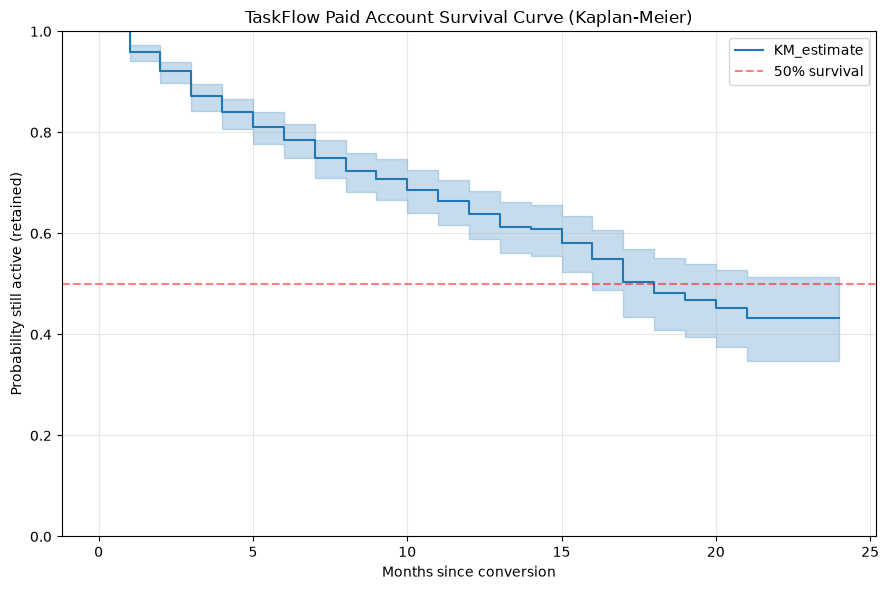

In [73]:
fig, ax = plt.subplots(figsize=(9, 6))

kmf.plot_survival_function(ax=ax)

ax.set_title("TaskFlow Paid Account Survival Curve (Kaplan-Meier)")
ax.set_xlabel("Months since conversion")
ax.set_ylabel("Probability still active (retained)")
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="50% survival")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

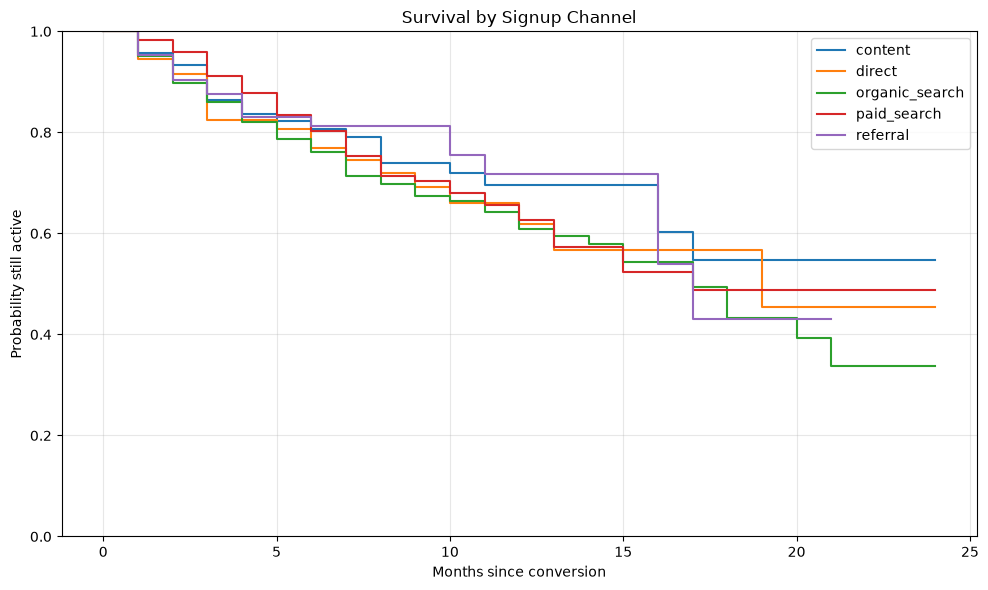

In [75]:
query = """
    SELECT cf.account_id, cf.months_retained, cf.churned, cf.signup_channel
    FROM `taskflow-growth-analytics.taskflow_dev.churn_features` cf
"""
df_seg = client.query(query).to_dataframe()

fig, ax = plt.subplots(figsize=(10, 6))

# one KM curve per channel
for channel in df_seg["signup_channel"].unique():
    mask = df_seg["signup_channel"] == channel
    kmf_seg = KaplanMeierFitter()
    kmf_seg.fit(
        df_seg[mask]["months_retained"],
        event_observed=df_seg[mask]["churned"].astype(int),
        label=channel
    )
    kmf_seg.plot_survival_function(ax=ax, ci_show=False)

ax.set_title("Survival by Signup Channel")
ax.set_xlabel("Months since conversion")
ax.set_ylabel("Probability still active")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Survival Analysis — Customer Lifetime (Kaplan-Meier)

**Method:** Kaplan-Meier on paid accounts. `months_retained` = duration, `churned` = event indicator. Correctly handles **censoring** (still-active accounts have unknown final lifespan — treated as "survived at least N months," not a completed lifespan).

**Result:** Median survival = **18 months** — half of paid accounts remain active 18 months after conversion. The survival curve flattens near 43% at month 24 (censored accounts still active at window's end).

**Segmented by channel:** Survival curves by signup channel did **not** show clean separation — curves are tangled through the well-populated early months, and tail differences (month 16+) fall within small-sample noise. Only weak consistency with the churn model (organic_search trends lowest). Honest conclusion: channel relates to churn directionally, but the effect is too small to produce clearly separated retention curves at this sample size.

**Why this matters:** Naively averaging `months_retained` would understate lifetime by treating active accounts as churned. Survival analysis + censoring gives the correct LTV anchor (~18 months median).